In [1]:
# Cell 1: Import required libraries for deep learning, image processing, and visualization.
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, losses, metrics
from tensorflow.keras.datasets.mnist import load_data as load_mnist
from skimage.metrics import structural_similarity as ssim

# Set random seeds to ensure reproducible experimental results.
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# Cell 2: Load MNIST using load_mnist, normalize pixels to [0, 1], and extract lab subsets.
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = load_mnist()

# Normalize pixel values from range [0, 255] to [0.0, 1.0].
x_train_raw = x_train_raw.astype(np.float32) / 255.0
x_test_raw = x_test_raw.astype(np.float32) / 255.0

# Extract lab subset of 10,000 training samples and 2,000 test samples.
x_train = x_train_raw[:10000]
y_train = y_train_raw[:10000]
x_test = x_test_raw[:2000]
y_test = y_test_raw[:2000]

# Expand channel dimension for convolutional architectures.
x_train_conv = np.expand_dims(x_train, axis=-1)
x_test_conv = np.expand_dims(x_test, axis=-1)

# Flatten images into 784-dimensional vectors for fully connected networks.
x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

# Output verified dataset shapes for lab confirmation.
print(f"Train Conv Shape: {x_train_conv.shape}, Test Conv Shape: {x_test_conv.shape}")
print(f"Train Flat Shape: {x_train_flat.shape}, Test Flat Shape: {x_test_flat.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train Conv Shape: (10000, 28, 28, 1), Test Conv Shape: (2000, 28, 28, 1)
Train Flat Shape: (10000, 784), Test Flat Shape: (2000, 784)


In [3]:
# Cell 3: Define utility functions to compute test MSE, MAE, and mean SSIM.
def compute_metrics(x_true, x_pred):
    # Compute Mean Squared Error across all test samples.
    mse_val = float(np.mean((x_true - x_pred) ** 2))
    # Compute Mean Absolute Error across all test samples.
    mae_val = float(np.mean(np.abs(x_true - x_pred)))
    # Reshape arrays to 2D image slices for SSIM computation.
    true_imgs = x_true.reshape((-1, 28, 28))
    pred_imgs = x_pred.reshape((-1, 28, 28))
    # Calculate SSIM individually per image with data range 1.0 and average.
    ssim_list = [
        ssim(true_imgs[i], pred_imgs[i], data_range=1.0)
        for i in range(len(true_imgs))
    ]
    mean_ssim = float(np.mean(ssim_list))
    return mse_val, mae_val, mean_ssim

In [4]:
# Cell 4: Build, compile, and train the fully connected autoencoder using the Functional API.
# Define functional encoder mapping 784 input pixels down to a 16-dimensional latent space.
enc_inputs = layers.Input(shape=(784,), name='enc_input')
x = layers.Dense(128, activation='relu', name='enc_dense1')(enc_inputs)
x = layers.Dense(32, activation='relu', name='enc_dense2')(x)
latent_repr = layers.Dense(16, activation='relu', name='latent_16')(x)
fc_encoder = models.Model(inputs=enc_inputs, outputs=latent_repr, name='FC_Encoder')

# Define functional decoder reconstructing 784 output pixels from the 16-dimensional latent vector.
dec_inputs = layers.Input(shape=(16,), name='dec_input')
y = layers.Dense(32, activation='relu', name='dec_dense1')(dec_inputs)
y = layers.Dense(128, activation='relu', name='dec_dense2')(y)
dec_outputs = layers.Dense(784, activation='sigmoid', name='output_flat')(y)
fc_decoder = models.Model(inputs=dec_inputs, outputs=dec_outputs, name='FC_Decoder')

# Connect encoder and decoder through a shared symbolic input tensor.
autoencoder_input = layers.Input(shape=(784,), name='ae_input')
autoencoder_output = fc_decoder(fc_encoder(autoencoder_input))
fc_autoencoder = models.Model(inputs=autoencoder_input, outputs=autoencoder_output, name='Fully_Connected_AE')

# Compile using Adam optimizer with 1e-3 learning rate and binary cross-entropy loss.
fc_autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy'
)

# Measure training time over 20 epochs with batch size 128.
start_time_fc = time.time()
fc_history = fc_autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat),
    verbose=1
)
time_fc = time.time() - start_time_fc

# Calculate evaluation metrics and count total parameters for FC-AE.
fc_preds_flat = fc_autoencoder.predict(x_test_flat)
fc_mse, fc_mae, fc_ssim = compute_metrics(x_test_flat, fc_preds_flat)
fc_params = fc_autoencoder.count_params()

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.3478 - val_loss: 0.2507
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2367 - val_loss: 0.2179
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2060 - val_loss: 0.1934
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1844 - val_loss: 0.1773
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1709 - val_loss: 0.1662
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1614 - val_loss: 0.1593
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1550 - val_loss: 0.1539
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1498 - val_loss: 0.1497
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1458 - val_loss: 0.1463
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1423 - val_loss: 0.1431
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1392 - val_loss: 0.1408
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1

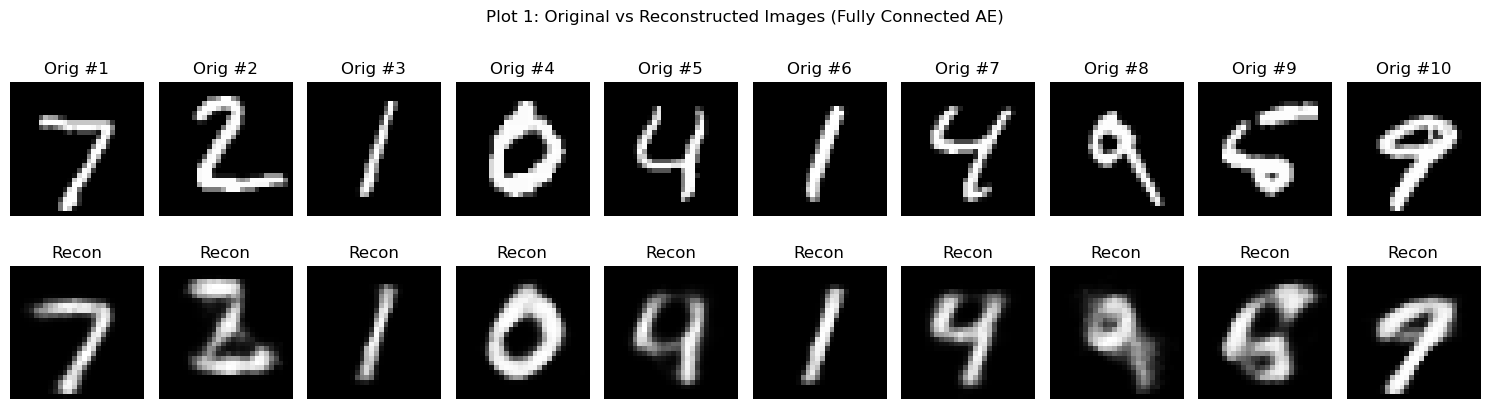

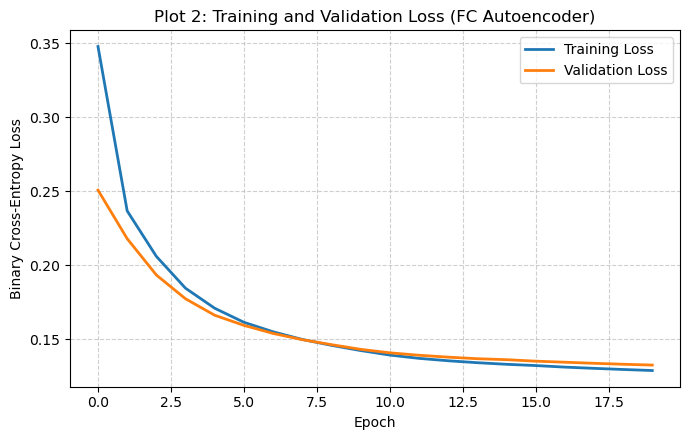


=== Table 1: Basic Fully Connected Autoencoder Metrics ===
           Metric   Value
         Test MSE 0.02389
         Test MAE 0.06188
        Mean SSIM  0.7193
       Parameters  211040
Training Time (s)   23.31


In [5]:

# Cell 5: Generate Plot 1 (Reconstructions), Plot 2 (Loss Curves), and print Table 1.
# Plot 1: Display 10 test images comparing original vs reconstructed images.
num_display = 10
fig, axes = plt.subplots(2, num_display, figsize=(15, 4.5))
for i in range(num_display):
    # Plot clean original test image.
    axes[0, i].imshow(x_test[i], cmap='gray')
    axes[0, i].set_title(f"Orig #{i+1}")
    axes[0, i].axis('off')
    # Plot FC-AE reconstructed test image.
    axes[1, i].imshow(fc_preds_flat[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title("Recon")
    axes[1, i].axis('off')
plt.suptitle("Plot 1: Original vs Reconstructed Images (Fully Connected AE)")
plt.tight_layout()
plt.show()

# Plot 2: Display training and validation reconstruction loss curves.
plt.figure(figsize=(7, 4.5))
plt.plot(fc_history.history['loss'], label='Training Loss', lw=2)
plt.plot(fc_history.history['val_loss'], label='Validation Loss', lw=2)
plt.title("Plot 2: Training and Validation Loss (FC Autoencoder)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Format and display Table 1: Reconstruction Metrics for Basic Autoencoder.
table1_df = pd.DataFrame({
    "Metric": ["Test MSE", "Test MAE", "Mean SSIM", "Parameters", "Training Time (s)"],
    "Value": [f"{fc_mse:.5f}", f"{fc_mae:.5f}", f"{fc_ssim:.4f}", f"{fc_params}", f"{time_fc:.2f}"]
})
print("\n=== Table 1: Basic Fully Connected Autoencoder Metrics ===")
print(table1_df.to_string(index=False))

In [6]:
# Cell 6: Build, compile, and train the Convolutional Autoencoder using the Functional API.
# Define functional convolutional encoder downsampling input to 7x7x64 feature maps.
cae_enc_inputs = layers.Input(shape=(28, 28, 1), name='cae_enc_input')
cx = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(cae_enc_inputs)
cx = layers.MaxPooling2D((2, 2), padding='same')(cx)
cx = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(cx)
cx = layers.MaxPooling2D((2, 2), padding='same')(cx)
cae_latent = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(cx)
cae_encoder = models.Model(inputs=cae_enc_inputs, outputs=cae_latent, name='CAE_Encoder')

# Define functional convolutional decoder upsampling feature maps back to 28x28x1.
cae_dec_inputs = layers.Input(shape=(7, 7, 64), name='cae_dec_input')
cy = layers.UpSampling2D((2, 2))(cae_dec_inputs)
cy = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(cy)
cy = layers.UpSampling2D((2, 2))(cy)
cae_dec_outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(cy)
cae_decoder = models.Model(inputs=cae_dec_inputs, outputs=cae_dec_outputs, name='CAE_Decoder')

# Connect CAE encoder and decoder through an explicit input tensor.
cae_input = layers.Input(shape=(28, 28, 1), name='cae_input')
cae_output = cae_decoder(cae_encoder(cae_input))
cae_autoencoder = models.Model(inputs=cae_input, outputs=cae_output, name='Convolutional_AE')

# Compile using Adam optimizer and binary cross-entropy loss.
cae_autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy'
)

# Measure training time over 20 epochs with batch size 128.
start_time_cae = time.time()
cae_history = cae_autoencoder.fit(
    x_train_conv, x_train_conv,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_conv, x_test_conv),
    verbose=1
)
time_cae = time.time() - start_time_cae

# Calculate evaluation metrics and parameter count for CAE.
cae_preds = cae_autoencoder.predict(x_test_conv)
cae_mse, cae_mae, cae_ssim = compute_metrics(x_test_conv, cae_preds)
cae_params = cae_autoencoder.count_params()

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - loss: 0.2208 - val_loss: 0.1000
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0923 - val_loss: 0.0853
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - loss: 0.0837 - val_loss: 0.0793
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - loss: 0.0798 - val_loss: 0.0765
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - loss: 0.0775 - val_loss: 0.0748
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0758 - val_loss: 0.0735
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - loss: 0.0747 - val_loss: 0.0732
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 167ms/step - loss: 0.0739 - val_loss: 0.0719
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - loss: 0.0730 - val_loss: 0.0721
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0725 - val_loss: 0.0717
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 0.0719 - val_loss: 0.0708
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 88m

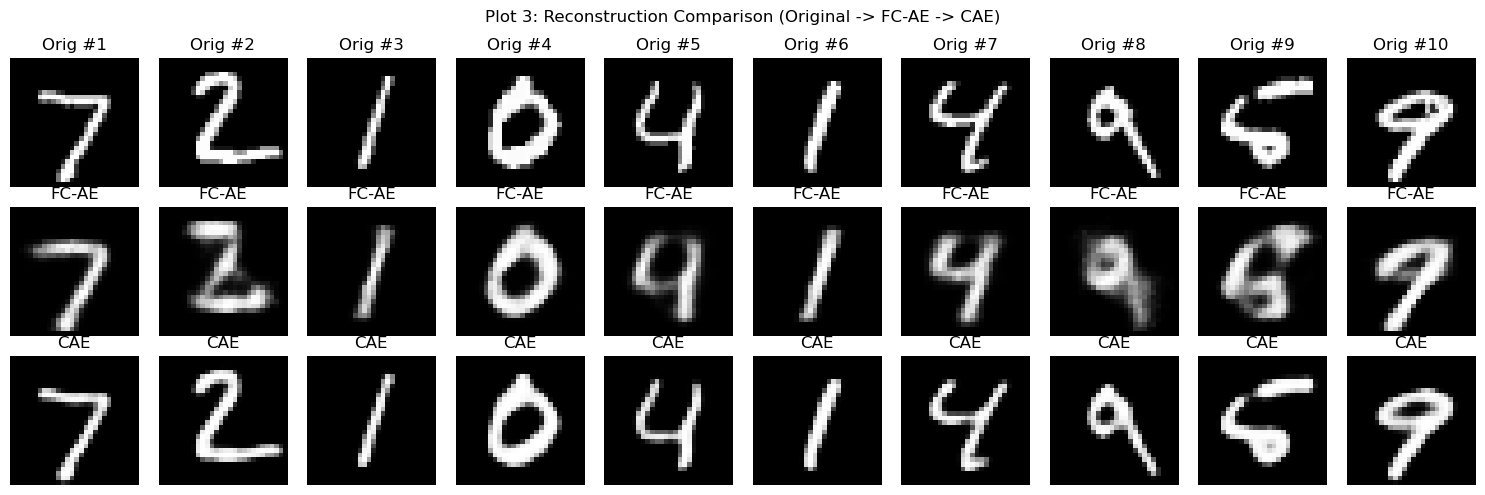


=== Table 2: Comparison Between FC-AE and CAE ===
             Model     MSE     MAE   SSIM  Parameters Time (s)
Fully Connected AE 0.02389 0.06188 0.7193      211040    23.31
  Convolutional AE 0.00270 0.01552 0.9724       74497   204.07


In [7]:
# Cell 7: Generate Plot 3 comparing FC-AE vs CAE reconstructions and output Table 2.
num_comp = 10
fig, axes = plt.subplots(3, num_comp, figsize=(15, 5))
for i in range(num_comp):
    # Display clean original digit.
    axes[0, i].imshow(x_test[i], cmap='gray')
    axes[0, i].set_title(f"Orig #{i+1}")
    axes[0, i].axis('off')
    # Display fully connected autoencoder reconstruction.
    axes[1, i].imshow(fc_preds_flat[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title("FC-AE")
    axes[1, i].axis('off')
    # Display convolutional autoencoder reconstruction.
    axes[2, i].imshow(cae_preds[i].squeeze(), cmap='gray')
    axes[2, i].set_title("CAE")
    axes[2, i].axis('off')
plt.suptitle("Plot 3: Reconstruction Comparison (Original -> FC-AE -> CAE)")
plt.tight_layout()
plt.show()

# Create comparison Table 2 for FC-AE versus CAE.
table2_df = pd.DataFrame({
    "Model": ["Fully Connected AE", "Convolutional AE"],
    "MSE": [f"{fc_mse:.5f}", f"{cae_mse:.5f}"],
    "MAE": [f"{fc_mae:.5f}", f"{cae_mae:.5f}"],
    "SSIM": [f"{fc_ssim:.4f}", f"{cae_ssim:.4f}"],
    "Parameters": [fc_params, cae_params],
    "Time (s)": [f"{time_fc:.2f}", f"{time_cae:.2f}"]
})
print("\n=== Table 2: Comparison Between FC-AE and CAE ===")
print(table2_df.to_string(index=False))

In [8]:
# Cell 8: Define noise functions, corrupt datasets, and train the Denoising CAE.
def add_gaussian_noise(images, sigma):
    # Add Gaussian random noise with specified standard deviation and clip to [0, 1].
    noise = np.random.normal(loc=0.0, scale=sigma, size=images.shape)
    return np.clip(images + noise, 0.0, 1.0).astype(np.float32)

def add_salt_and_pepper_noise(images, prob):
    # Introduce salt-and-pepper noise by randomly setting pixels to 0 or 1.
    corrupted = np.copy(images)
    rnd = np.random.rand(*images.shape)
    corrupted[rnd < (prob / 2.0)] = 0.0
    corrupted[rnd > 1.0 - (prob / 2.0)] = 1.0
    return corrupted.astype(np.float32)

# Corrupt training and testing sets with baseline Gaussian noise sigma = 0.2.
x_train_noisy_02 = add_gaussian_noise(x_train_conv, sigma=0.2)
x_test_noisy_02 = add_gaussian_noise(x_test_conv, sigma=0.2)

# Instantiate a cloned convolutional architecture for the denoising autoencoder.
dae_model = models.clone_model(cae_autoencoder)
dae_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy'
)

# Train mapping corrupted noisy input to clean target image.
start_time_dae = time.time()
dae_history = dae_model.fit(
    x_train_noisy_02, x_train_conv,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_02, x_test_conv),
    verbose=1
)
time_dae = time.time() - start_time_dae

# Predict clean denoised reconstructions from noisy inputs.
dae_preds_02 = dae_model.predict(x_test_noisy_02)
dae_mse, dae_mae, dae_ssim = compute_metrics(x_test_conv, dae_preds_02)
dae_params = dae_model.count_params()

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 0.2421 - val_loss: 0.1116
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0995 - val_loss: 0.0932
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0892 - val_loss: 0.0853
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0851 - val_loss: 0.0838
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0829 - val_loss: 0.0811
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0812 - val_loss: 0.0791
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0800 - val_loss: 0.0780
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0791 - val_loss: 0.0774
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.0783 - val_loss: 0.0766
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 0.0777 - val_loss: 0.0761
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0771 - val_loss: 0.0756
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0

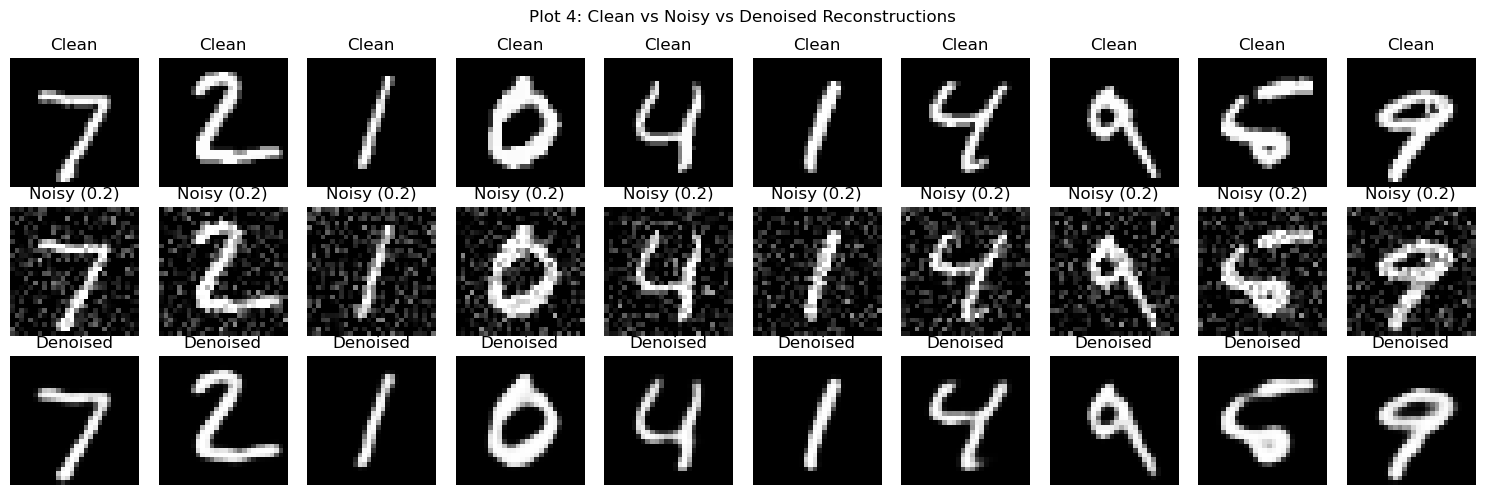

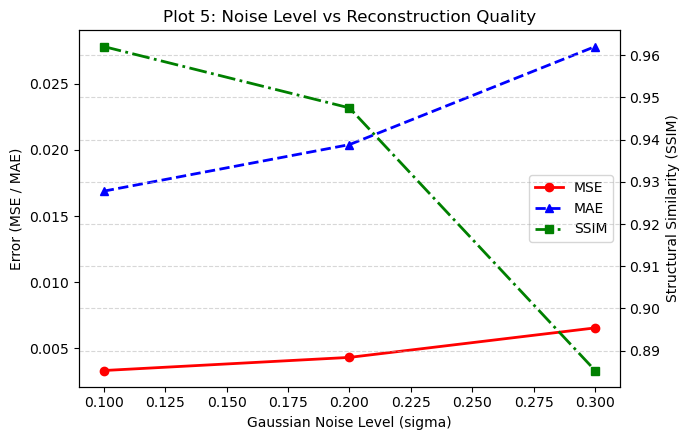


=== Table 3: Reconstruction Quality Across Noise Levels ===
 Noise Level (sigma)     MSE     MAE   SSIM
                 0.1 0.00333 0.01688 0.9621
                 0.2 0.00433 0.02039 0.9475
                 0.3 0.00655 0.02780 0.8853


In [ ]:
# Cell 9: Generate Plot 4 (Denoising visual), evaluate across noise levels, Plot 5, and Table 3.
# Plot 4: Clean vs Noisy vs Denoised images for 10 test samples.
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for i in range(10):
    axes[0, i].imshow(x_test_conv[i].squeeze(), cmap='gray')
    axes[0, i].set_title("Clean")
    axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy_02[i].squeeze(), cmap='gray')
    axes[1, i].set_title("Noisy (0.2)")
    axes[1, i].axis('off')
    axes[2, i].imshow(dae_preds_02[i].squeeze(), cmap='gray')
    axes[2, i].set_title("Denoised")
    axes[2, i].axis('off')
plt.suptitle("Plot 4: Clean vs Noisy vs Denoised Reconstructions")
plt.tight_layout()
plt.show()

# Evaluate denoising performance over Gaussian noise levels sigma in {0.1, 0.2, 0.3}.
noise_levels = [0.1, 0.2, 0.3]
noise_mse_list, noise_mae_list, noise_ssim_list = [], [], []

for sig in noise_levels:
    x_test_noisy_sig = add_gaussian_noise(x_test_conv, sigma=sig)
    preds_sig = dae_model.predict(x_test_noisy_sig, verbose=0)
    cur_mse, cur_mae, cur_ssim = compute_metrics(x_test_conv, preds_sig)
    noise_mse_list.append(cur_mse)
    noise_mae_list.append(cur_mae)
    noise_ssim_list.append(cur_ssim)

# Plot 5: Noise level vs Reconstruction Quality across MSE, MAE, and SSIM.
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()
p1 = ax1.plot(noise_levels, noise_mse_list, 'ro-', label='MSE', lw=2)
p2 = ax1.plot(noise_levels, noise_mae_list, 'b^--', label='MAE', lw=2)
p3 = ax2.plot(noise_levels, noise_ssim_list, 'gs-.', label='SSIM', lw=2)

ax1.set_xlabel("Gaussian Noise Level (sigma)")
ax1.set_ylabel("Error (MSE / MAE)")
ax2.set_ylabel("Structural Similarity (SSIM)")
all_plots = p1 + p2 + p3
labs = [p.get_label() for p in all_plots]
ax1.legend(all_plots, labs, loc='center right')
plt.title("Plot 5: Noise Level vs Reconstruction Quality")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print Table 3 reporting quantitative metrics against noise levels.
table3_df = pd.DataFrame({
    "Noise Level (sigma)": noise_levels,
    "MSE": [f"{v:.5f}" for v in noise_mse_list],
    "MAE": [f"{v:.5f}" for v in noise_mae_list],
    "SSIM": [f"{v:.4f}" for v in noise_ssim_list]
})
print("\n=== Table 3: Reconstruction Quality Across Noise Levels ===")
print(table3_df.to_string(index=False))

In [10]:
# Cell 10: Implement sampling layer, encoder, decoder, custom VAE model, and compile.
class Sampling(layers.Layer):
    # Reparameterization trick sampling z = mu + sigma * epsilon.
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Build VAE encoder mapping input images to 2D Gaussian parameters mu and log_var.
latent_dim = 2
enc_inputs = layers.Input(shape=(28, 28, 1), name='vae_input')
x = layers.Conv2D(32, (3, 3), strides=2, activation='relu', padding='same')(enc_inputs)
x = layers.Conv2D(64, (3, 3), strides=2, activation='relu', padding='same')(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
vae_encoder = models.Model(enc_inputs, [z_mean, z_log_var, z], name='VAE_Encoder')

# Build VAE decoder mapping latent vector z to reconstructed image.
latent_inputs = layers.Input(shape=(latent_dim,), name='z_sampling')
x = layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
dec_outputs = layers.Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same')(x)
vae_decoder = models.Model(latent_inputs, dec_outputs, name='VAE_Decoder')

# Subclass Keras Model to compute reconstruction loss and analytic KL divergence loss.
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # Sum binary cross-entropy across pixel spatial dimensions.
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            # Calculate closed-form KL divergence with standard normal prior.
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(
                losses.binary_crossentropy(data, reconstruction),
                axis=(1, 2)
            )
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Instantiate, compile, and train the VAE model.
vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

start_time_vae = time.time()
vae_history = vae.fit(
    x_train_conv,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_conv,),
    verbose=1
)
time_vae = time.time() - start_time_vae
vae_params = vae_encoder.count_params() + vae_decoder.count_params()


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - kl_loss: 1.7066 - loss: 298.1570 - reconstruction_loss: 296.4503 - val_kl_loss: 0.4486 - val_loss: 205.9753 - val_reconstruction_loss: 205.5268
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - kl_loss: 1.3394 - loss: 207.4703 - reconstruction_loss: 206.1308 - val_kl_loss: 2.9242 - val_loss: 196.7320 - val_reconstruction_loss: 193.8078
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - kl_loss: 2.9154 - loss: 201.1217 - reconstruction_loss: 198.2063 - val_kl_loss: 3.4768 - val_loss: 193.7116 - val_reconstruction_loss: 190.2348
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - kl_loss: 3.0204 - loss: 198.4507 - reconstruction_loss: 195.4303 - val_kl_loss: 3.8841 - val_loss: 191.5347 - val_reconstruction_loss: 187.6505
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - kl_loss: 3.1729 - loss: 196.7996 - reconstruction_loss: 193.6267 - val_kl_loss: 3.3781 - val_loss: 190.2288 - val_reconstruction_loss: 186.8506
Epoch 6/20
79/

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


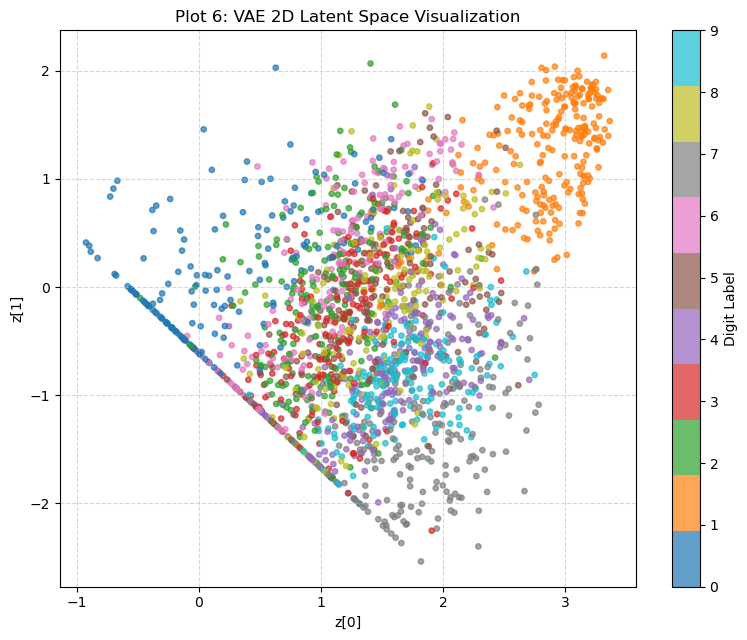

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


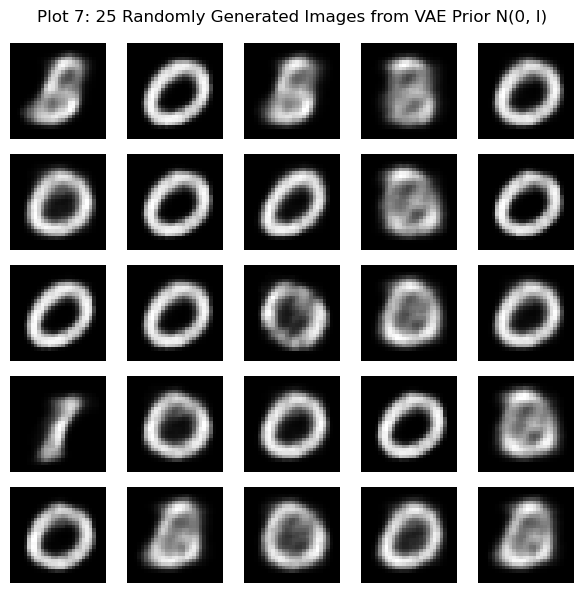

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


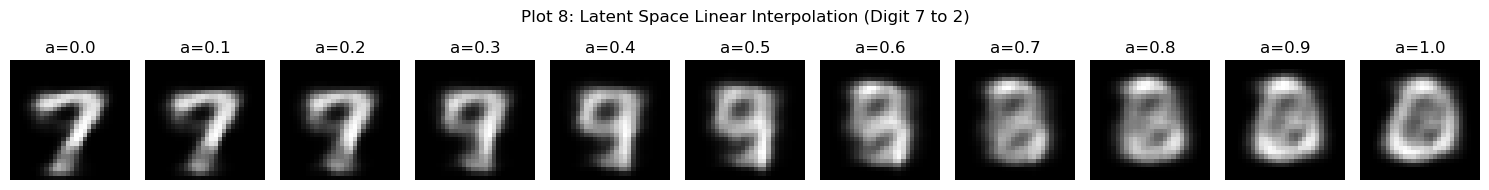

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

=== Table 4: Variational Autoencoder Performance Metrics ===
         VAE Metric    Value
Reconstruction Loss 167.7767
            KL Loss   5.1721
         Total Loss 172.9489
           Test MSE  0.04941
           Test MAE  0.11741
          Mean SSIM   0.3936


In [11]:
# Cell 11: Generate Plot 6 (Latent space), Plot 7 (Generated samples), Plot 8 (Interpolation), and Table 4.
# Plot 6: 2D Latent space scatter plot colored by digit class labels.
z_mean_test, _, _ = vae.encoder.predict(x_test_conv, batch_size=128)
plt.figure(figsize=(8, 6.5))
scatter = plt.scatter(z_mean_test[:, 0], z_mean_test[:, 1], c=y_test, cmap='tab10', alpha=0.7, s=15)
plt.colorbar(scatter, label='Digit Label')
plt.title("Plot 6: VAE 2D Latent Space Visualization")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot 7: Generate 25 new digit images sampled from standard normal prior.
random_latents = np.random.normal(size=(25, latent_dim))
generated_images = vae.decoder.predict(random_latents)

fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle("Plot 7: 25 Randomly Generated Images from VAE Prior N(0, I)")
plt.tight_layout()
plt.show()

# Plot 8: Latent space linear interpolation between two test points.
idx_a, idx_b = 0, 1
z_a = z_mean_test[idx_a]
z_b = z_mean_test[idx_b]
alphas = np.linspace(0.0, 1.0, 11)
interpolated_latents = np.array([(1.0 - a) * z_a + a * z_b for a in alphas])
interpolated_images = vae.decoder.predict(interpolated_latents)

fig, axes = plt.subplots(1, 11, figsize=(15, 2))
for i, alpha in enumerate(alphas):
    axes[i].imshow(interpolated_images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"a={alpha:.1f}")
    axes[i].axis('off')
plt.suptitle(f"Plot 8: Latent Space Linear Interpolation (Digit {y_test[idx_a]} to {y_test[idx_b]})")
plt.tight_layout()
plt.show()

# Compute reconstruction metrics for the trained VAE on the test set.
vae_reconstructions = vae.decoder.predict(z_mean_test)
vae_mse, vae_mae, vae_ssim = compute_metrics(x_test_conv, vae_reconstructions)

# Format and display Table 4: Quantitative VAE metrics.
final_recon_loss = vae_history.history['reconstruction_loss'][-1]
final_kl_loss = vae_history.history['kl_loss'][-1]
final_total_loss = vae_history.history['loss'][-1]

table4_df = pd.DataFrame({
    "VAE Metric": ["Reconstruction Loss", "KL Loss", "Total Loss", "Test MSE", "Test MAE", "Mean SSIM"],
    "Value": [f"{final_recon_loss:.4f}", f"{final_kl_loss:.4f}", f"{final_total_loss:.4f}",
              f"{vae_mse:.5f}", f"{vae_mae:.5f}", f"{vae_ssim:.4f}"]
})
print("\n=== Table 4: Variational Autoencoder Performance Metrics ===")
print(table4_df.to_string(index=False))

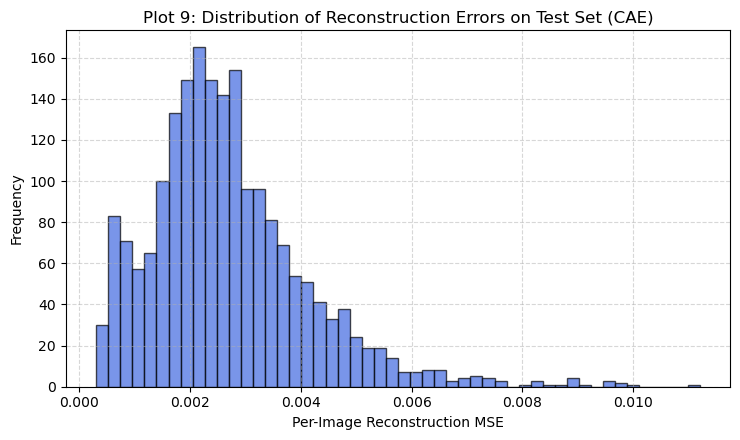

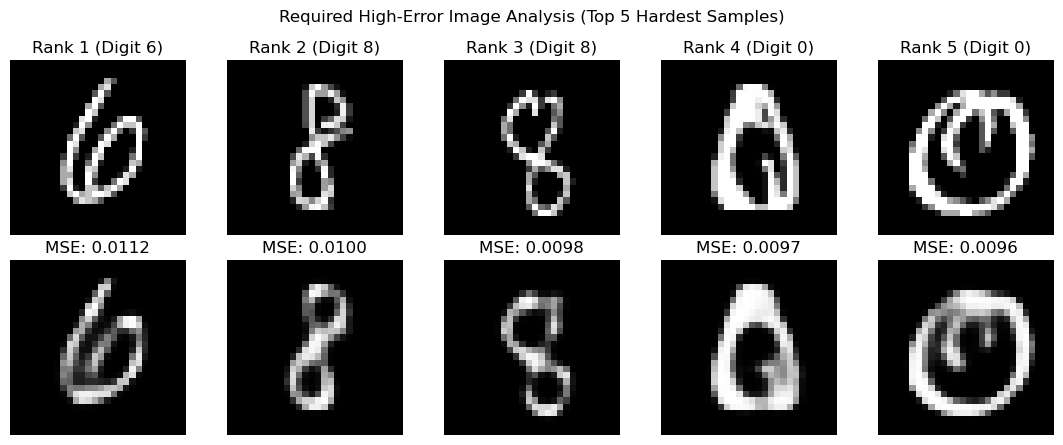


=== Table 5: High-Error Test Samples (CAE) ===
 Sample Rank  Test Index  Digit Label Reconstruction MSE
           1        1969            6            0.01120
           2        1320            8            0.01005
           3        1855            8            0.00982
           4         895            0            0.00971
           5        1526            0            0.00957


In [12]:
# Cell 12: Calculate per-image MSE distribution for CAE, plot histogram (Plot 9), and extract Top 5 hardest images.
# Calculate per-image reconstruction MSE across the test dataset.
per_image_mse = np.mean((x_test_conv - cae_preds) ** 2, axis=(1, 2, 3))

# Plot 9: Distribution of reconstruction errors across test set.
plt.figure(figsize=(7.5, 4.5))
plt.hist(per_image_mse, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Plot 9: Distribution of Reconstruction Errors on Test Set (CAE)")
plt.xlabel("Per-Image Reconstruction MSE")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Identify indices of the 5 test images with the largest reconstruction error.
top5_indices = np.argsort(per_image_mse)[-5:][::-1]

# Display Table 5 and corresponding original versus reconstructed visualizations.
fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
top5_records = []
for rank, idx in enumerate(top5_indices):
    # Plot original high-error image.
    axes[0, rank].imshow(x_test_conv[idx].squeeze(), cmap='gray')
    axes[0, rank].set_title(f"Rank {rank+1} (Digit {y_test[idx]})")
    axes[0, rank].axis('off')
    # Plot reconstructed image.
    axes[1, rank].imshow(cae_preds[idx].squeeze(), cmap='gray')
    axes[1, rank].set_title(f"MSE: {per_image_mse[idx]:.4f}")
    axes[1, rank].axis('off')
    top5_records.append({
        "Sample Rank": rank + 1,
        "Test Index": idx,
        "Digit Label": y_test[idx],
        "Reconstruction MSE": f"{per_image_mse[idx]:.5f}"
    })
plt.suptitle("Required High-Error Image Analysis (Top 5 Hardest Samples)")
plt.tight_layout()
plt.show()

table5_df = pd.DataFrame(top5_records)
print("\n=== Table 5: High-Error Test Samples (CAE) ===")
print(table5_df.to_string(index=False))

In [13]:
# Cell 13: Compile and display consolidated comparative results for all four core architectures.
consolidated_df = pd.DataFrame({
    "Model": ["FC Autoencoder", "Conv. Autoencoder", "Denoising CAE", "VAE (Latent=2)"],
    "MSE": [f"{fc_mse:.5f}", f"{cae_mse:.5f}", f"{dae_mse:.5f}", f"{vae_mse:.5f}"],
    "MAE": [f"{fc_mae:.5f}", f"{cae_mae:.5f}", f"{dae_mae:.5f}", f"{vae_mae:.5f}"],
    "SSIM": [f"{fc_ssim:.4f}", f"{cae_ssim:.4f}", f"{dae_ssim:.4f}", f"{vae_ssim:.4f}"],
    "Parameters": [fc_params, cae_params, dae_params, vae_params],
    "Time (s)": [f"{time_fc:.2f}", f"{time_cae:.2f}", f"{time_dae:.2f}", f"{time_vae:.2f}"]
})
print("\n=== Section 25: Consolidated Experimental Results ===")
print(consolidated_df.to_string(index=False))


=== Section 25: Consolidated Experimental Results ===
            Model     MSE     MAE   SSIM  Parameters Time (s)
   FC Autoencoder 0.02389 0.06188 0.7193      211040    23.31
Conv. Autoencoder 0.00270 0.01552 0.9724       74497   204.07
    Denoising CAE 0.00429 0.02031 0.9479       74497   128.39
   VAE (Latent=2) 0.04941 0.11741 0.3936      134165   109.84


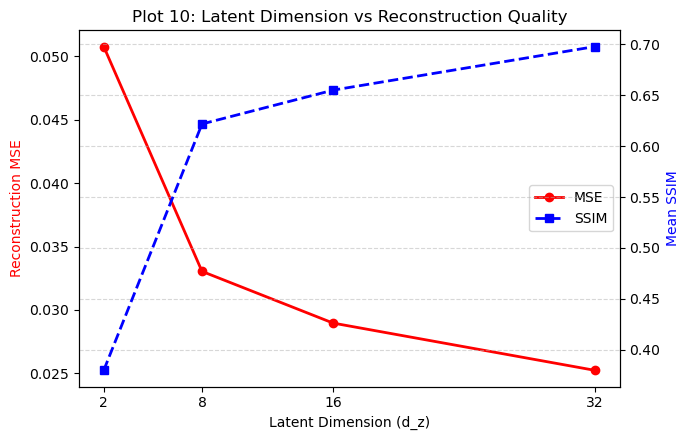


=== Table 7: Additional Latent-Dimension Study ===
 Latent Dimension     MSE   SSIM  Parameters
                2 0.05077 0.3797      210130
                8 0.03304 0.6217      210520
               16 0.02897 0.6549      211040
               32 0.02524 0.6978      212080


In [14]:
# Cell 14: Study effect of varying bottleneck dimension d_z in {2, 8, 16, 32} on FC-AE using Functional API (Plot 10 & Table 7).
latent_dimensions = [2, 8, 16, 32]
latent_mse_list, latent_ssim_list, latent_param_list = [], [], []

for d_z in latent_dimensions:
    # Build functional autoencoder configured with varying bottleneck dimension.
    inputs = layers.Input(shape=(784,), name=f'in_{d_z}')
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(32, activation='relu')(x)
    latent = layers.Dense(d_z, activation='relu', name=f'latent_{d_z}')(x)
    y = layers.Dense(32, activation='relu')(latent)
    y = layers.Dense(128, activation='relu')(y)
    outputs = layers.Dense(784, activation='sigmoid')(y)

    ae = models.Model(inputs=inputs, outputs=outputs, name=f'FC_AE_{d_z}')
    ae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')
    ae.fit(x_train_flat, x_train_flat, epochs=10, batch_size=128, verbose=0)

    # Evaluate reconstruction metrics on test images.
    preds = ae.predict(x_test_flat, verbose=0)
    cur_mse, _, cur_ssim = compute_metrics(x_test_flat, preds)
    latent_mse_list.append(cur_mse)
    latent_ssim_list.append(cur_ssim)
    latent_param_list.append(ae.count_params())

# Plot 10: Latent Dimension vs Reconstruction MSE and SSIM.
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()
line1 = ax1.plot(latent_dimensions, latent_mse_list, 'ro-', label='MSE', lw=2)
line2 = ax2.plot(latent_dimensions, latent_ssim_list, 'bs--', label='SSIM', lw=2)
ax1.set_xlabel("Latent Dimension (d_z)")
ax1.set_ylabel("Reconstruction MSE", color='r')
ax2.set_ylabel("Mean SSIM", color='b')
ax1.set_xticks(latent_dimensions)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')
plt.title("Plot 10: Latent Dimension vs Reconstruction Quality")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Output Table 7: Latent dimension comparison.
table7_df = pd.DataFrame({
    "Latent Dimension": latent_dimensions,
    "MSE": [f"{v:.5f}" for v in latent_mse_list],
    "SSIM": [f"{v:.4f}" for v in latent_ssim_list],
    "Parameters": latent_param_list
})
print("\n=== Table 7: Additional Latent-Dimension Study ===")
print(table7_df.to_string(index=False))

In [15]:
# Cell 15: Implement additional exercises: noise comparison, transposed convolutions, and beta-VAE scaling using Functional API.
# Exercise 2: Compare Gaussian noise (sigma=0.2) vs Salt-and-Pepper noise (prob=0.10) on DAE.
x_test_sp = add_salt_and_pepper_noise(x_test_conv, prob=0.10)
preds_sp = dae_model.predict(x_test_sp, verbose=0)
mse_sp, mae_sp, ssim_sp = compute_metrics(x_test_conv, preds_sp)

print("\n--- Additional Exercise 2: Noise Robustness Comparison ---")
ex2_df = pd.DataFrame({
    "Noise Type": ["Gaussian (sigma=0.2)", "Salt & Pepper (p=0.10)"],
    "MSE": [f"{dae_mse:.5f}", f"{mse_sp:.5f}"],
    "MAE": [f"{dae_mae:.5f}", f"{mae_sp:.5f}"],
    "SSIM": [f"{dae_ssim:.4f}", f"{ssim_sp:.4f}"]
})
print(ex2_df.to_string(index=False))

# Exercise 4: Construct CAE using functional Conv2DTranspose decoder layers.
trans_inputs = layers.Input(shape=(28, 28, 1), name='trans_in')
enc_feat = cae_encoder(trans_inputs)
ty = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(enc_feat)
trans_outputs = layers.Conv2DTranspose(1, (3, 3), strides=2, activation='sigmoid', padding='same')(ty)
cae_trans = models.Model(inputs=trans_inputs, outputs=trans_outputs, name='CAE_Transposed')

cae_trans.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy')
cae_trans.fit(x_train_conv, x_train_conv, epochs=10, batch_size=128, verbose=0)

trans_preds = cae_trans.predict(x_test_conv, verbose=0)
mse_trans, mae_trans, ssim_trans = compute_metrics(x_test_conv, trans_preds)

print("\n--- Additional Exercise 4: UpSampling2D vs Conv2DTranspose Decoder ---")
ex4_df = pd.DataFrame({
    "Decoder Architecture": ["UpSampling2D + Conv2D", "Conv2DTranspose"],
    "MSE": [f"{cae_mse:.5f}", f"{mse_trans:.5f}"],
    "SSIM": [f"{cae_ssim:.4f}", f"{ssim_trans:.4f}"],
    "Parameters": [cae_params, cae_trans.count_params()]
})
print(ex4_df.to_string(index=False))

# Exercise 6: Evaluate effect of scaling KL-loss contribution (beta-VAE) with beta in {0.5, 1.0, 2.0}.
beta_values = [0.5, 1.0, 2.0]
beta_results = []

for b in beta_values:
    # Custom training step incorporating beta weighting on KL divergence term.
    class BetaVAE(VAE):
        def train_step(self, data):
            if isinstance(data, tuple):
                data = data[0]
            with tf.GradientTape() as tape:
                z_mean, z_log_var, z = self.encoder(data)
                recon = self.decoder(z)
                recon_loss = tf.reduce_mean(tf.reduce_sum(losses.binary_crossentropy(data, recon), axis=(1, 2)))
                kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
                total_loss = recon_loss + (b * kl_loss)
            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(recon_loss)
            self.kl_loss_tracker.update_state(kl_loss)
            return {
                "loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.reconstruction_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()
            }

    bvae = BetaVAE(vae_encoder, vae_decoder)
    bvae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
    bvae.fit(x_train_conv, epochs=5, batch_size=128, verbose=0)

    # Measure test set SSIM and final training losses under beta weighting.
    z_m, _, _ = bvae.encoder.predict(x_test_conv, batch_size=128, verbose=0)
    b_recon = bvae.decoder.predict(z_m, verbose=0)
    b_mse, _, b_ssim = compute_metrics(x_test_conv, b_recon)
    beta_results.append({
        "Beta Weight": b,
        "Recon Loss": f"{float(bvae.reconstruction_loss_tracker.result()):.4f}",
        "KL Loss": f"{float(bvae.kl_loss_tracker.result()):.4f}",
        "Test MSE": f"{b_mse:.5f}",
        "Mean SSIM": f"{b_ssim:.4f}"
    })

print("\n--- Additional Exercise 6: Beta-VAE Loss Weighting Study ---")
print(pd.DataFrame(beta_results).to_string(index=False))


--- Additional Exercise 2: Noise Robustness Comparison ---
            Noise Type     MSE     MAE   SSIM
  Gaussian (sigma=0.2) 0.00429 0.02031 0.9479
Salt & Pepper (p=0.10) 0.00659 0.02554 0.8978

--- Additional Exercise 4: UpSampling2D vs Conv2DTranspose Decoder ---
 Decoder Architecture     MSE   SSIM  Parameters
UpSampling2D + Conv2D 0.00270 0.9724       74497
      Conv2DTranspose 0.00285 0.9684       74497

--- Additional Exercise 6: Beta-VAE Loss Weighting Study ---
 Beta Weight Recon Loss KL Loss Test MSE Mean SSIM
         0.5   158.9521  7.1567  0.04748    0.4247
         1.0   156.4457  6.3016  0.04679    0.4345
         2.0   156.0675  5.2565  0.04639    0.4413
